# 第 1 天：进入 ChemWorld 因果世界环境

第一次运行隐藏反应器，完成一条可记录、可评分、可回放的实验轨迹。

今天的重点不是背 Python 语法，而是把 Python 当作实验台：提出条件、执行动作、读取观测，并把每一步留下可复现证据。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | A. 进入世界 |
| 难度 | 入门 1/3 |
| 先修 | 会打开 Jupyter，能运行一个 Python 单元。 |
| 今天只解决 | 第一次运行 ChemWorld，看懂 action、observation、reward、info 和 trajectory 的关系。 |
| 今天不要求 | 不追求最高分，也不要求理解完整反应机理。 |
| 本日交付 | 一条可回放轨迹、一张实验图、一个下一轮实验假设。 |
| 下一步如何复用 | Day 2 会用这条轨迹检查 ontology、单位和 physical constitution。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 确认环境入口 | 运行导入单元，检查 kernel、项目根目录和输出目录。 | 能解释 `gym.make("ChemWorld")` 返回什么。 |
| 0:30-1:00 | 读懂事件动作 | 逐条阅读 add/heat/terminate/measure 的操作含义。 | 写下一个完整实验 recipe。 |
| 1:00-1:30 | 执行第一条实验 | 运行手工事件序列，观察 reward、terminated、info。 | 得到第一张轨迹表。 |
| 1:30-2:00 | 保存可复现证据 | 导出 JSONL，定位 action、observation、raw_signal 字段。 | 留下可回放轨迹文件。 |
| 2:00-2:30 | 画第一张图 | 从轨迹中选择 score、risk 或 cost 生成图。 | 得到一张能解释的实验图。 |
| 2:30-3:00 | 形成下一轮假设 | 根据结果写机制假设和下一轮实验建议。 | 提交 3 句话反思。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 按给定 recipe 跑通一次 reaction-to-assay，保存轨迹并指出每一步的 operation。 |
| 进阶任务 | 修改一个温度或时间参数，比较 score、risk 和 final assay 的变化。 |
| 挑战任务 | 写出一个“为什么下一轮该这样改条件”的化工假设。 |
| 反思问题 | 今天你看到的是隐藏真实状态，还是仪器返回的观测？这两者为什么不能混淆？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 至少新增 6 条不同 recipe，覆盖 2 个温度、2 个时间和 2 个溶剂/催化剂选择。 |
| 2 | 把每条实验的 action、observation、reward、risk、cost 保存成一张表。 |
| 3 | 至少画 2 张图：score/risk 随条件变化图，以及最终 best experiment 摘要图。 |
| 4 | 写 300 字实验日志：你认为哪一步最影响结果，下一轮为什么这样改。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(1)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day01


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


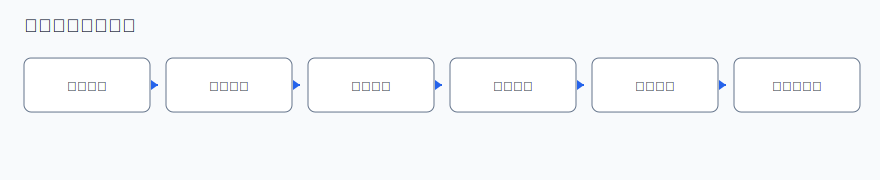

In [2]:
tu.display_tutorial_header(
    day=1,
    title='进入 ChemWorld 虚拟实验室',
    subtitle='第一次运行隐藏反应器，完成一条可记录、可评分、可回放的实验轨迹。',
    focus=[
        'Gym 环境入口',
        '事件动作 API',
        'final assay 与 reward 的区别',
        '实验轨迹记录',
    ],
    deliverables=[
        '一张实验轨迹表',
        '一份 trajectory JSONL',
        '一个下一轮实验假设',
    ],
    project_link='今天产出的每一步记录，都会成为后续 benchmark trajectory 的基础。',
)
tu.display_course_map(1)
display(tu.workflow_svg())


In [3]:
tu.display_api_card()

In [4]:
tu.display_score_terms()

## 第 1 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一张来自自己实验的轨迹表或 JSONL 文件
- 一张由自己实验数据生成的图
- 一个有化工意义的机制假设
- 一个下一轮实验建议
- 一条关于 GPT 或其他助手使用方式的记录


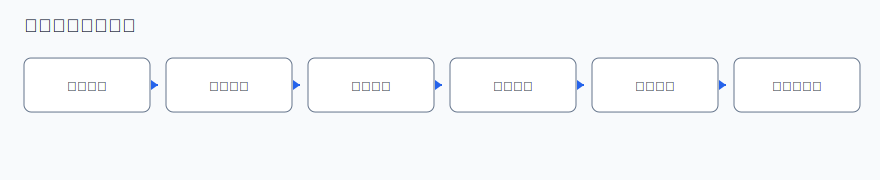

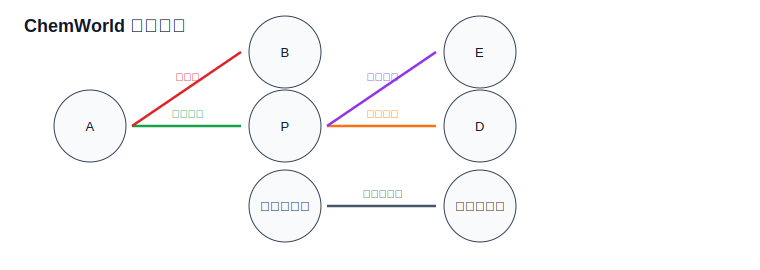

In [6]:
display(tu.workflow_svg())
display(tu.reaction_network_svg())

## 1.1 一个实验不是一个函数调用

`ChemWorld` 使用事件序列，而不是一次性黑箱函数。一个典型实验包括：

1. 加溶剂；
2. 加反应物；
3. 加催化剂；
4. 加热或等待，让 ODE transition kernel 演化隐藏状态；
5. 终止反应；
6. 用仪器测量。

注意：在测量之前，产率、选择性和转化率并不可见。


In [7]:
manual_events = [
    {"operation": "add_solvent", "volume_L": 0.030, "solvent": 2},
    {"operation": "add_reagent", "amount_mol": 0.010},
    {
        "operation": "add_catalyst",
        "catalyst_amount_mol": 0.00025,
        "catalyst": 1,
    },
    {
        "operation": "heat",
        "target_temperature_K": 388.0,
        "duration_s": 1500.0,
        "stirring_speed_rpm": 720.0,
    },
    {"operation": "measure", "instrument": "hplc"},
    {"operation": "wait", "duration_s": 600.0, "stirring_speed_rpm": 720.0},
    {"operation": "terminate"},
    {"operation": "measure", "instrument": "final_assay"},
]

trajectory = tu.run_events(manual_events, seed=7)
trajectory[
    [
        "step",
        "operation",
        "instrument",
        "reward",
        "leaderboard_score",
        "yield",
        "selectivity",
        "conversion",
        "cost",
        "risk",
        "observed_keys",
    ]
]

,step,operation,instrument,reward,leaderboard_score,yield,selectivity,conversion,cost,risk,observed_keys
0,1,add_solvent,None,0.0000,NaN,NaN,NaN,NaN,0.0384,0.0777,"cost, safety_risk, score"
1,2,add_reagent,None,0.0000,NaN,NaN,NaN,NaN,0.0684,0.0942,"cost, safety_risk, score"
2,3,add_catalyst,None,0.0000,NaN,NaN,NaN,NaN,0.2484,0.0942,"cost, safety_risk, score"
3,4,heat,None,0.0000,NaN,NaN,NaN,NaN,0.2609,0.1593,"cost, safety_risk, score"
4,5,measure,hplc,0.4079,NaN,0.6633,0.6687,NaN,0.3409,0.1593,"yield, selectivity, byproduct_signal, purity, ..."
5,6,wait,None,0.4198,NaN,0.6633,0.6687,NaN,0.3426,0.1104,"yield, selectivity, byproduct_signal, purity, ..."
6,7,terminate,None,0.4198,NaN,0.6633,0.6687,NaN,0.3426,0.1104,"yield, selectivity, byproduct_signal, purity, ..."
7,8,measure,final_assay,0.4405,0.4405,0.5891,0.5957,1.0,0.5026,0.1104,"yield, selectivity, conversion, byproduct_sign..."


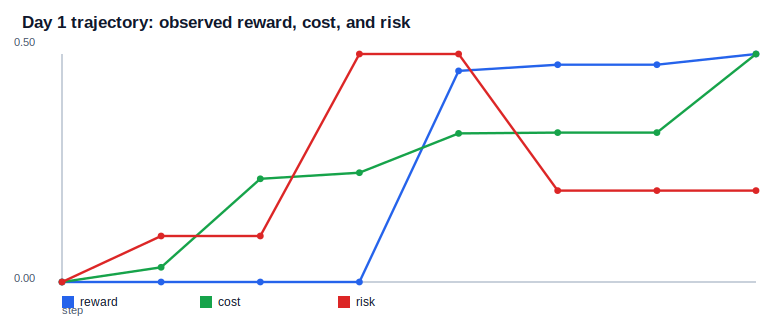

In [8]:
display(
    tu.line_svg(
        trajectory,
        x="step",
        ys=["reward", "cost", "risk"],
        title="Day 1 trajectory: observed reward, cost, and risk",
    )
)

## 当天练习

修改 `target_temperature_K`、`duration_s` 或 `solvent`，重新运行实验。
观察三个问题：

- HPLC 之后哪些字段仍然没有被测到？
- final assay 和 HPLC 的 `observed_keys` 有什么不同？
- 最高 reward 是否一定意味着最低风险？


## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [9]:
tu.display_reflection_box(
    [
        '这次实验中哪些信息是真正由仪器观测到的？',
        '如果只剩一次实验预算，你会把下一步放在哪里？',
    ]
)
